# Phase 11 – Hyperparameter Sweeps

This notebook visualizes hyperparameter sweep outputs generated by the C++ ML Core practical workflow.

It reads exported CSV files only. It does **not** train models or reimplement model logic in Python.

Input files:

```txt
outputs/practical-exercises/regression/hyperparameter_sweep.csv
outputs/practical-exercises/binary-classification/hyperparameter_sweep.csv
outputs/practical-exercises/multiclass-classification/hyperparameter_sweep.csv
outputs/practical-exercises/unsupervised/hyperparameter_sweep.csv
```

Covered sweep types:

```txt
parameter vs metric
parameter vs loss-style metric
parameter vs inertia
parameter vs explained variance
```


## 1. Load exported sweep outputs

The notebook is expected to be run from:

```txt
notebooks/practical-workflows/
```

so paths are resolved relative to the notebook location.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_ROOT = Path("../../outputs/practical-exercises")

sweep_paths = {
    "regression": OUTPUT_ROOT / "regression" / "hyperparameter_sweep.csv",
    "binary_classification": OUTPUT_ROOT / "binary-classification" / "hyperparameter_sweep.csv",
    "multiclass_classification": OUTPUT_ROOT / "multiclass-classification" / "hyperparameter_sweep.csv",
    "unsupervised": OUTPUT_ROOT / "unsupervised" / "hyperparameter_sweep.csv",
}

for name, path in sweep_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required sweep file for {name}: {path}")

sweeps = {
    name: pd.read_csv(path)
    for name, path in sweep_paths.items()
}

for name, dataframe in sweeps.items():
    print(name, dataframe.shape)


regression (32, 9)
binary_classification (144, 9)
multiclass_classification (12, 9)
unsupervised (11, 9)


## 2. Inspect sweep schema

All sweep files use the same long schema:

```txt
run_id
workflow
dataset
model
split
param_name
param_value
metric
value
```

For multi-parameter sweeps, each metric appears once per parameter. This makes the output easy to filter and pivot in Pandas.


In [2]:
for name, dataframe in sweeps.items():
    print(f"\n{name}")
    display(dataframe.head())



regression


,run_id,workflow,dataset,model,split,param_name,param_value,metric,value
0,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,test,n_estimators,5.00,mse,0.000531
1,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,test,learning_rate,0.03,mse,0.000531
2,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,test,n_estimators,5.00,rmse,0.023038
3,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,test,learning_rate,0.03,rmse,0.023038
4,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,test,n_estimators,5.00,mae,0.017064



binary_classification


,run_id,workflow,dataset,model,split,param_name,param_value,metric,value
0,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,test,learning_rate,0.005,accuracy,0.750000
1,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,test,ridge_lambda,0.000,accuracy,0.750000
2,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,test,learning_rate,0.005,precision,0.190476
3,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,test,ridge_lambda,0.000,precision,0.190476
4,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,test,learning_rate,0.005,recall,0.235294



multiclass_classification


,run_id,workflow,dataset,model,split,param_name,param_value,metric,value
0,knn_k1,multiclass_classification,wine,KNNClassifier,test,k,1,accuracy,0.972222
1,knn_k1,multiclass_classification,wine,KNNClassifier,test,k,1,macro_precision,0.958333
2,knn_k1,multiclass_classification,wine,KNNClassifier,test,k,1,macro_recall,0.983333
3,knn_k1,multiclass_classification,wine,KNNClassifier,test,k,1,macro_f1,0.969231
4,knn_k3,multiclass_classification,wine,KNNClassifier,test,k,3,accuracy,0.972222



unsupervised


,run_id,workflow,dataset,model,split,param_name,param_value,metric,value
0,pca_components_2,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,2,explained_variance_ratio_1,0.346838
1,pca_components_2,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,2,explained_variance_ratio_2,0.282644
2,pca_components_2,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,2,cumulative_explained_variance_ratio,0.629482
3,pca_components_3,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,3,explained_variance_ratio_1,0.346838
4,pca_components_3,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,3,explained_variance_ratio_2,0.282644


## 3. Helper functions

These helpers are used only for visualization and analysis of exported results.

They do not implement model logic.


In [3]:
def prepare_sweep_frame(dataframe: pd.DataFrame) -> pd.DataFrame:
    result = dataframe.copy()

    result["param_value_numeric"] = pd.to_numeric(
        result["param_value"],
        errors="coerce",
    )

    result["value"] = pd.to_numeric(
        result["value"],
        errors="raise",
    )

    return result


def plot_parameter_vs_metric(
    dataframe: pd.DataFrame,
    *,
    model: str,
    param_name: str,
    metric: str,
    title: str,
) -> None:
    subset = dataframe[
        (dataframe["model"] == model)
        & (dataframe["param_name"] == param_name)
        & (dataframe["metric"] == metric)
    ].copy()

    if subset.empty:
        print(f"No rows for model={model}, param_name={param_name}, metric={metric}")
        return

    subset = subset.sort_values("param_value_numeric")

    plt.figure(figsize=(8, 4))
    plt.plot(
        subset["param_value_numeric"],
        subset["value"],
        marker="o",
    )
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


def plot_grouped_parameter_vs_metric(
    dataframe: pd.DataFrame,
    *,
    model: str,
    x_param: str,
    group_param: str,
    metric: str,
    title: str,
) -> None:
    subset = dataframe[
        (dataframe["model"] == model)
        & (dataframe["metric"] == metric)
    ].copy()

    if subset.empty:
        print(f"No rows for model={model}, metric={metric}")
        return

    run_params = (
        subset[["run_id", "param_name", "param_value"]]
        .drop_duplicates()
        .pivot(index="run_id", columns="param_name", values="param_value")
        .reset_index()
    )

    run_metrics = (
        subset[["run_id", "value"]]
        .drop_duplicates()
    )

    merged = run_metrics.merge(run_params, on="run_id", how="inner")

    if x_param not in merged.columns or group_param not in merged.columns:
        print(f"Missing parameter columns: {x_param}, {group_param}")
        display(merged.head())
        return

    merged[x_param] = pd.to_numeric(merged[x_param], errors="coerce")
    merged[group_param] = pd.to_numeric(merged[group_param], errors="coerce")
    merged = merged.sort_values([group_param, x_param])

    plt.figure(figsize=(8, 4))

    for group_value, group in merged.groupby(group_param):
        plt.plot(
            group[x_param],
            group["value"],
            marker="o",
            label=f"{group_param}={group_value:g}",
        )

    plt.title(title)
    plt.xlabel(x_param)
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


def best_runs_by_metric(
    dataframe: pd.DataFrame,
    *,
    model: str,
    metric: str,
    higher_is_better: bool,
    top_n: int = 5,
) -> pd.DataFrame:
    subset = dataframe[
        (dataframe["model"] == model)
        & (dataframe["metric"] == metric)
    ].copy()

    if subset.empty:
        return subset

    run_metrics = subset[["run_id", "workflow", "dataset", "model", "metric", "value"]].drop_duplicates()

    run_params = (
        subset[["run_id", "param_name", "param_value"]]
        .drop_duplicates()
        .sort_values(["run_id", "param_name"])
        .groupby("run_id")
        .apply(
            lambda group: ", ".join(
                f"{row.param_name}={row.param_value}"
                for row in group.itertuples(index=False)
            ),
            include_groups=False,
        )
        .reset_index(name="params")
    )

    result = run_metrics.merge(run_params, on="run_id", how="left")
    result = result.sort_values("value", ascending=not higher_is_better)

    return result.head(top_n).reset_index(drop=True)


for name in list(sweeps.keys()):
    sweeps[name] = prepare_sweep_frame(sweeps[name])


## 4. Regression sweep – GradientBoostingRegressor

This section visualizes the effect of:

```txt
n_estimators
learning_rate
```

on regression metrics.


In [4]:
regression_sweep = sweeps["regression"]

display(
    best_runs_by_metric(
        regression_sweep,
        model="GradientBoostingRegressor",
        metric="mse",
        higher_is_better=False,
    )
)

display(
    best_runs_by_metric(
        regression_sweep,
        model="GradientBoostingRegressor",
        metric="r2",
        higher_is_better=True,
    )
)


,run_id,workflow,dataset,model,metric,value,params
0,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,mse,0.000531,"learning_rate=0.03, n_estimators=5.0"
1,gb_n10_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,mse,0.000537,"learning_rate=0.03, n_estimators=10.0"
2,gb_n5_lr0.1,regression,stock_ohlcv_engineered,GradientBoostingRegressor,mse,0.000544,"learning_rate=0.1, n_estimators=5.0"
3,gb_n10_lr0.1,regression,stock_ohlcv_engineered,GradientBoostingRegressor,mse,0.000557,"learning_rate=0.1, n_estimators=10.0"


,run_id,workflow,dataset,model,metric,value,params
0,gb_n5_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,r2,-0.011458,"learning_rate=0.03, n_estimators=5.0"
1,gb_n10_lr0.03,regression,stock_ohlcv_engineered,GradientBoostingRegressor,r2,-0.024025,"learning_rate=0.03, n_estimators=10.0"
2,gb_n5_lr0.1,regression,stock_ohlcv_engineered,GradientBoostingRegressor,r2,-0.036731,"learning_rate=0.1, n_estimators=5.0"
3,gb_n10_lr0.1,regression,stock_ohlcv_engineered,GradientBoostingRegressor,r2,-0.061217,"learning_rate=0.1, n_estimators=10.0"


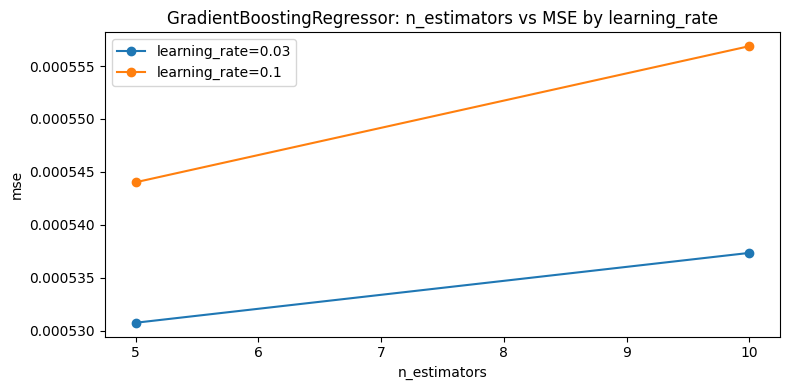

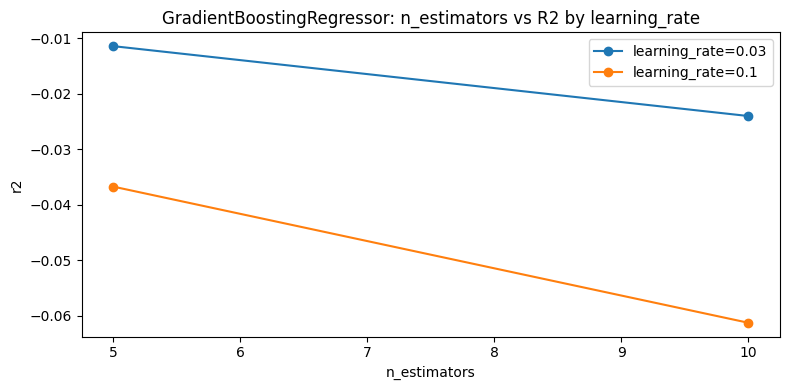

In [5]:
plot_grouped_parameter_vs_metric(
    regression_sweep,
    model="GradientBoostingRegressor",
    x_param="n_estimators",
    group_param="learning_rate",
    metric="mse",
    title="GradientBoostingRegressor: n_estimators vs MSE by learning_rate",
)

plot_grouped_parameter_vs_metric(
    regression_sweep,
    model="GradientBoostingRegressor",
    x_param="n_estimators",
    group_param="learning_rate",
    metric="r2",
    title="GradientBoostingRegressor: n_estimators vs R2 by learning_rate",
)


## 5. Binary classification sweeps

This section visualizes binary classification sweep behavior.

Models:

```txt
LogisticRegression
DecisionTreeClassifier
RandomForestClassifier
TinyMLPBinaryClassifier
```

Important metrics:

```txt
accuracy
precision
recall
f1
```

For the KC1 defect dataset, F1 and recall are especially important because the dataset is imbalanced.


In [6]:
binary_sweep = sweeps["binary_classification"]

for model_name in [
    "LogisticRegression",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "TinyMLPBinaryClassifier",
]:
    print(f"\nBest F1 runs – {model_name}")
    display(
        best_runs_by_metric(
            binary_sweep,
            model=model_name,
            metric="f1",
            higher_is_better=True,
        )
    )



Best F1 runs – LogisticRegression


,run_id,workflow,dataset,model,metric,value,params
0,logistic_lr0.005_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,f1,0.210526,"learning_rate=0.005, ridge_lambda=0.0"
1,logistic_lr0.005_ridge0.01,binary_classification,nasa_kc1_software_defects,LogisticRegression,f1,0.210526,"learning_rate=0.005, ridge_lambda=0.01"
2,logistic_lr0.01_ridge0,binary_classification,nasa_kc1_software_defects,LogisticRegression,f1,0.206897,"learning_rate=0.01, ridge_lambda=0.0"
3,logistic_lr0.01_ridge0.01,binary_classification,nasa_kc1_software_defects,LogisticRegression,f1,0.206897,"learning_rate=0.01, ridge_lambda=0.01"



Best F1 runs – DecisionTreeClassifier


,run_id,workflow,dataset,model,metric,value,params
0,decision_tree_depth2_leaf1,binary_classification,nasa_kc1_software_defects,DecisionTreeClassifier,f1,0.375000,"max_depth=2.0, min_samples_leaf=1.0"
1,decision_tree_depth2_leaf10,binary_classification,nasa_kc1_software_defects,DecisionTreeClassifier,f1,0.375000,"max_depth=2.0, min_samples_leaf=10.0"
2,decision_tree_depth4_leaf1,binary_classification,nasa_kc1_software_defects,DecisionTreeClassifier,f1,0.301887,"max_depth=4.0, min_samples_leaf=1.0"
3,decision_tree_depth4_leaf10,binary_classification,nasa_kc1_software_defects,DecisionTreeClassifier,f1,0.285714,"max_depth=4.0, min_samples_leaf=10.0"



Best F1 runs – RandomForestClassifier


,run_id,workflow,dataset,model,metric,value,params
0,random_forest_trees10_maxfeat4,binary_classification,nasa_kc1_software_defects,RandomForestClassifier,f1,0.441176,"max_features=4.0, n_estimators=10.0"
1,random_forest_trees5_maxfeat4,binary_classification,nasa_kc1_software_defects,RandomForestClassifier,f1,0.394737,"max_features=4.0, n_estimators=5.0"
2,random_forest_trees5_maxfeat8,binary_classification,nasa_kc1_software_defects,RandomForestClassifier,f1,0.394737,"max_features=8.0, n_estimators=5.0"
3,random_forest_trees10_maxfeat8,binary_classification,nasa_kc1_software_defects,RandomForestClassifier,f1,0.376812,"max_features=8.0, n_estimators=10.0"



Best F1 runs – TinyMLPBinaryClassifier


,run_id,workflow,dataset,model,metric,value,params
0,tiny_mlp_h8_lr0.05_e50,binary_classification,nasa_kc1_software_defects,TinyMLPBinaryClassifier,f1,0.111111,"hidden_units=8.0, learning_rate=0.05, max_epoc..."
1,tiny_mlp_h4_lr0.01_e50,binary_classification,nasa_kc1_software_defects,TinyMLPBinaryClassifier,f1,0.000000,"hidden_units=4.0, learning_rate=0.01, max_epoc..."
2,tiny_mlp_h4_lr0.05_e50,binary_classification,nasa_kc1_software_defects,TinyMLPBinaryClassifier,f1,0.000000,"hidden_units=4.0, learning_rate=0.05, max_epoc..."
3,tiny_mlp_h8_lr0.01_e50,binary_classification,nasa_kc1_software_defects,TinyMLPBinaryClassifier,f1,0.000000,"hidden_units=8.0, learning_rate=0.01, max_epoc..."


### LogisticRegression: learning rate and regularization

This visualizes how `learning_rate` and `ridge_lambda` affect F1.


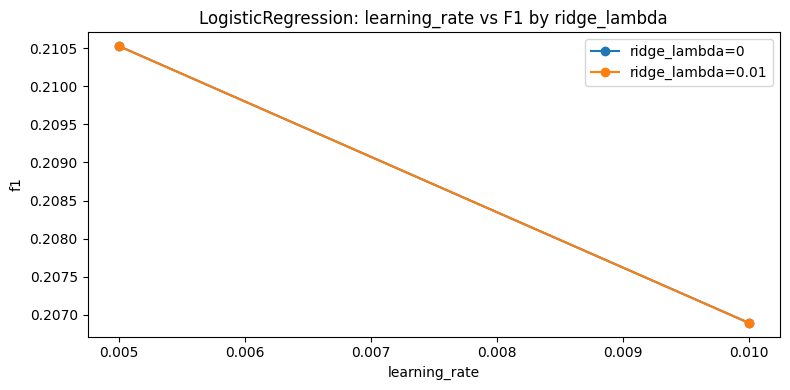

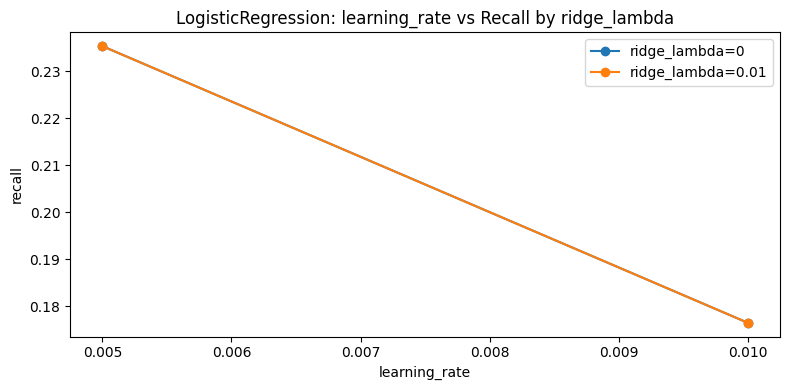

In [7]:
plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="LogisticRegression",
    x_param="learning_rate",
    group_param="ridge_lambda",
    metric="f1",
    title="LogisticRegression: learning_rate vs F1 by ridge_lambda",
)

plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="LogisticRegression",
    x_param="learning_rate",
    group_param="ridge_lambda",
    metric="recall",
    title="LogisticRegression: learning_rate vs Recall by ridge_lambda",
)


### DecisionTreeClassifier: depth and stopping control

This visualizes how `max_depth` and `min_samples_leaf` affect F1 and recall.


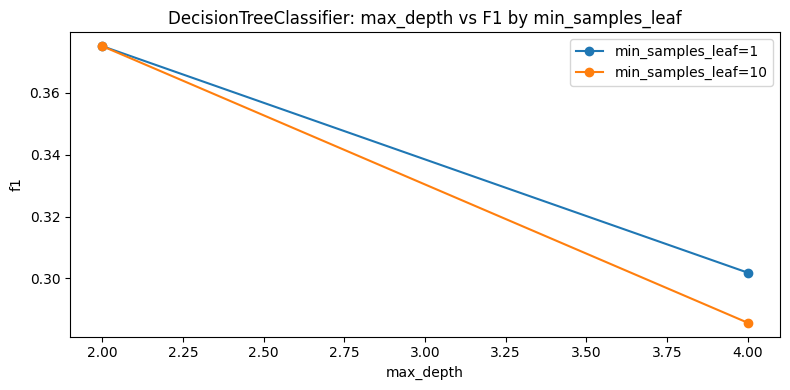

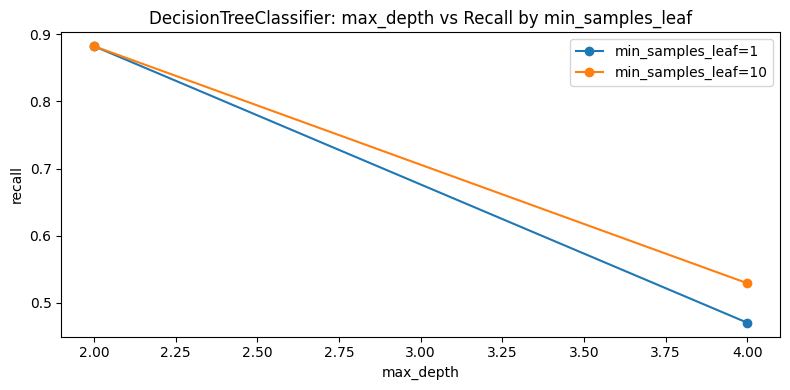

In [8]:
plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="DecisionTreeClassifier",
    x_param="max_depth",
    group_param="min_samples_leaf",
    metric="f1",
    title="DecisionTreeClassifier: max_depth vs F1 by min_samples_leaf",
)

plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="DecisionTreeClassifier",
    x_param="max_depth",
    group_param="min_samples_leaf",
    metric="recall",
    title="DecisionTreeClassifier: max_depth vs Recall by min_samples_leaf",
)


### RandomForestClassifier: number of trees and feature subsampling

This visualizes how `n_estimators` and `max_features` affect F1 and recall.


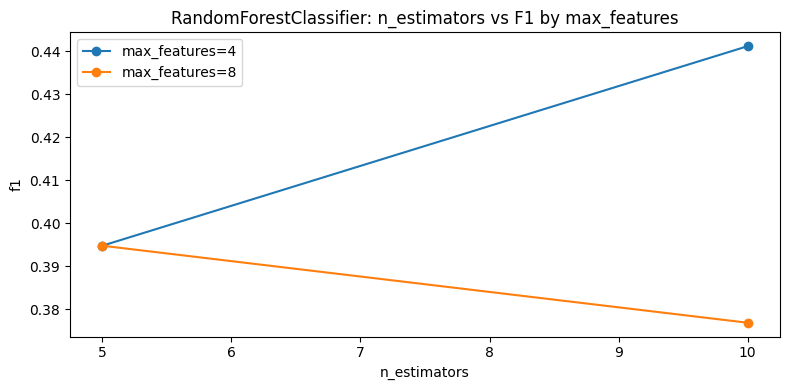

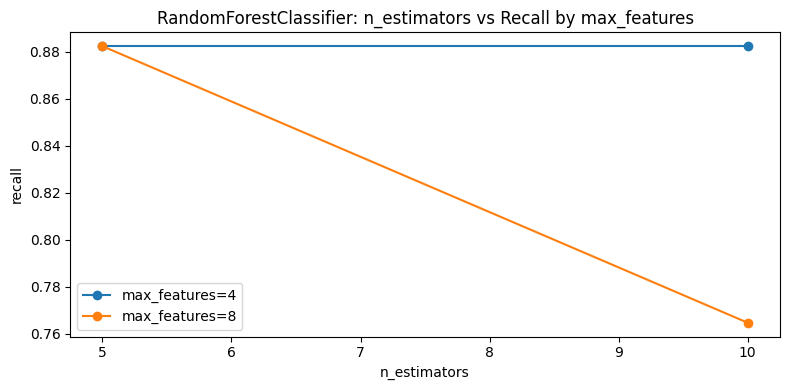

In [9]:
plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="RandomForestClassifier",
    x_param="n_estimators",
    group_param="max_features",
    metric="f1",
    title="RandomForestClassifier: n_estimators vs F1 by max_features",
)

plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="RandomForestClassifier",
    x_param="n_estimators",
    group_param="max_features",
    metric="recall",
    title="RandomForestClassifier: n_estimators vs Recall by max_features",
)


### TinyMLPBinaryClassifier: hidden units and learning rate

This visualizes how `hidden_units` and `learning_rate` affect F1 and accuracy.

The current sanity sweep uses a fixed value for `max_epochs`.


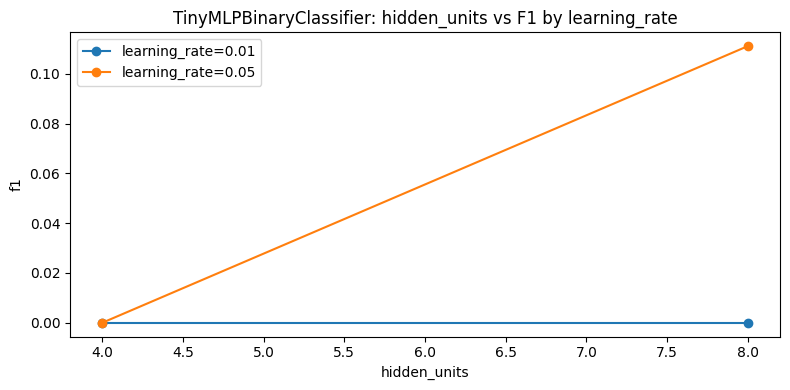

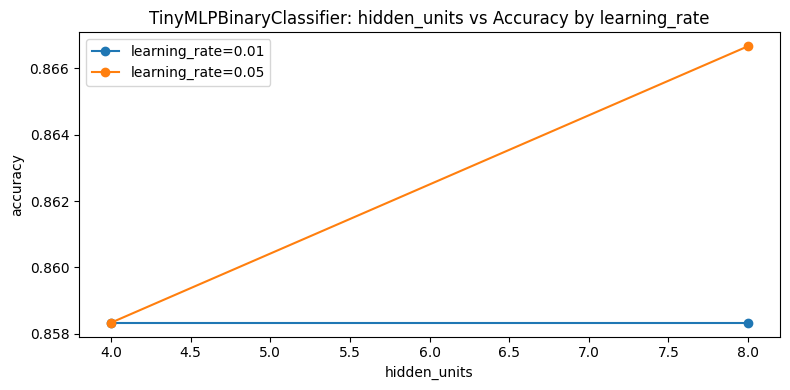

In [10]:
plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="TinyMLPBinaryClassifier",
    x_param="hidden_units",
    group_param="learning_rate",
    metric="f1",
    title="TinyMLPBinaryClassifier: hidden_units vs F1 by learning_rate",
)

plot_grouped_parameter_vs_metric(
    binary_sweep,
    model="TinyMLPBinaryClassifier",
    x_param="hidden_units",
    group_param="learning_rate",
    metric="accuracy",
    title="TinyMLPBinaryClassifier: hidden_units vs Accuracy by learning_rate",
)


## 6. Multiclass sweep – KNNClassifier

This section visualizes the effect of:

```txt
k
```

on multiclass metrics.


,run_id,workflow,dataset,model,metric,value,params
0,knn_k5,multiclass_classification,wine,KNNClassifier,macro_f1,0.973909,k=5
1,knn_k1,multiclass_classification,wine,KNNClassifier,macro_f1,0.969231,k=1
2,knn_k3,multiclass_classification,wine,KNNClassifier,macro_f1,0.969231,k=3


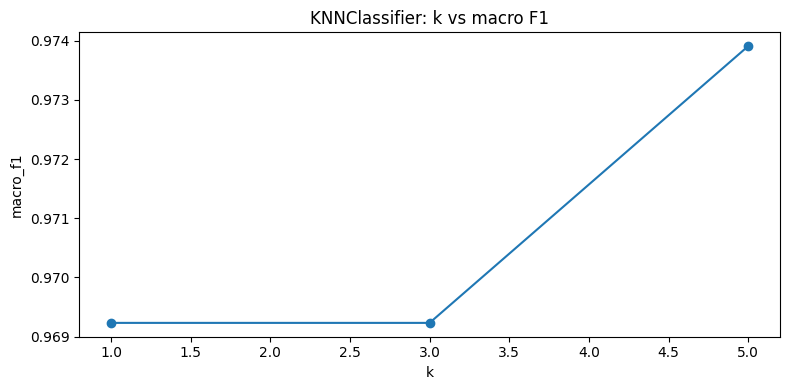

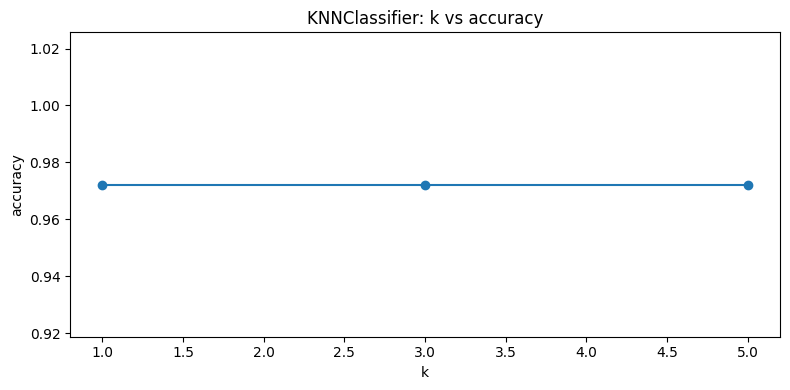

In [11]:
multiclass_sweep = sweeps["multiclass_classification"]

display(
    best_runs_by_metric(
        multiclass_sweep,
        model="KNNClassifier",
        metric="macro_f1",
        higher_is_better=True,
    )
)

plot_parameter_vs_metric(
    multiclass_sweep,
    model="KNNClassifier",
    param_name="k",
    metric="macro_f1",
    title="KNNClassifier: k vs macro F1",
)

plot_parameter_vs_metric(
    multiclass_sweep,
    model="KNNClassifier",
    param_name="k",
    metric="accuracy",
    title="KNNClassifier: k vs accuracy",
)


## 7. Unsupervised sweep – PCA explained variance

This section visualizes how the number of PCA components changes cumulative explained variance.


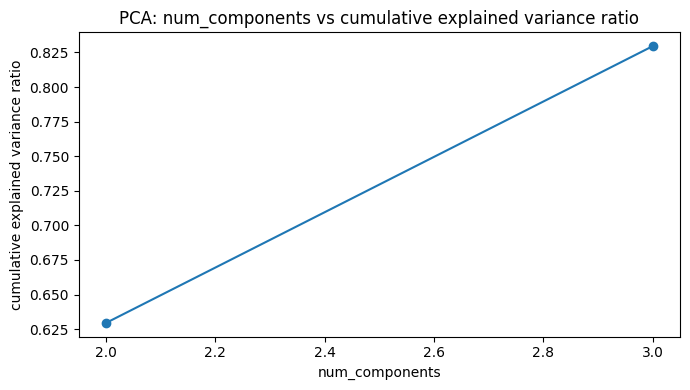

,run_id,workflow,dataset,model,split,param_name,param_value,metric,value,param_value_numeric
2,pca_components_2,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,2,cumulative_explained_variance_ratio,0.629482,2
6,pca_components_3,unsupervised,stock_ohlcv_engineered,PCA,full,num_components,3,cumulative_explained_variance_ratio,0.829574,3


In [12]:
unsupervised_sweep = sweeps["unsupervised"]

pca_cumulative = unsupervised_sweep[
    (unsupervised_sweep["model"] == "PCA")
    & (unsupervised_sweep["metric"] == "cumulative_explained_variance_ratio")
].copy()

pca_cumulative = pca_cumulative.sort_values("param_value_numeric")

plt.figure(figsize=(7, 4))
plt.plot(
    pca_cumulative["param_value_numeric"],
    pca_cumulative["value"],
    marker="o",
)
plt.title("PCA: num_components vs cumulative explained variance ratio")
plt.xlabel("num_components")
plt.ylabel("cumulative explained variance ratio")
plt.tight_layout()
plt.show()

pca_cumulative


## 8. Unsupervised sweep – KMeans inertia

This section visualizes how the number of clusters changes KMeans inertia.

Lower inertia means more compact clusters, but lower inertia alone does not prove that clusters are more meaningful.


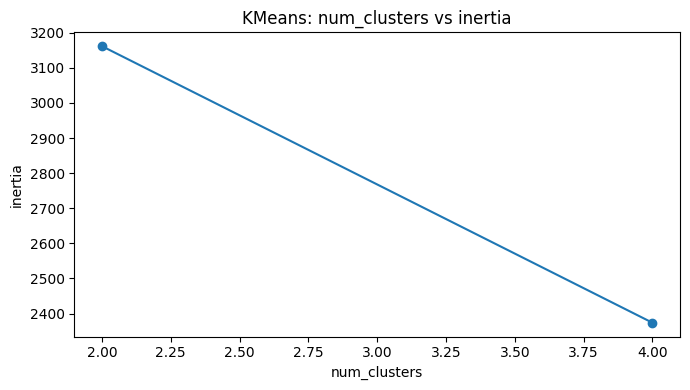

,run_id,workflow,dataset,model,split,param_name,param_value,metric,value,param_value_numeric
7,kmeans_k2,unsupervised,stock_ohlcv_engineered,KMeans,full,num_clusters,2,inertia,3161.578349,2
9,kmeans_k4,unsupervised,stock_ohlcv_engineered,KMeans,full,num_clusters,4,inertia,2373.775576,4


In [13]:
kmeans_inertia = unsupervised_sweep[
    (unsupervised_sweep["model"] == "KMeans")
    & (unsupervised_sweep["metric"] == "inertia")
].copy()

kmeans_inertia = kmeans_inertia.sort_values("param_value_numeric")

plt.figure(figsize=(7, 4))
plt.plot(
    kmeans_inertia["param_value_numeric"],
    kmeans_inertia["value"],
    marker="o",
)
plt.title("KMeans: num_clusters vs inertia")
plt.xlabel("num_clusters")
plt.ylabel("inertia")
plt.tight_layout()
plt.show()

kmeans_inertia


## 9. Interpretation notes

This notebook is for visualization only.

Important interpretation rules:

```txt
Regression:
  lower MSE/RMSE/MAE is better
  higher R2 is better

Binary classification:
  accuracy can be misleading on imbalanced data
  recall and F1 are often more informative for defect detection

Multiclass classification:
  macro metrics help evaluate class-balanced behavior

PCA:
  more components usually retain more variance

KMeans:
  more clusters usually reduce inertia
  inertia alone does not define the best number of clusters
```

The purpose of the sweep notebook is to connect parameter changes to model behavior, not to search for globally optimal production hyperparameters.
